# Solvers and stiffness

jbubble integrates with the explicit `Dopri5` solver by default, which suits microbubbles. Small or viscous bubbles make the equations stiff. Measure where the implicit solver of `SolverConfig.stiff()` wins, see how `max_steps` and `converged` report a solve that runs out of steps, and see why a stiff problem needs the implicit solver for gradients.

In [ ]:
# Install jbubble on Google Colab, or anywhere it's missing.
import importlib.util

if importlib.util.find_spec("jbubble") is None:
    %pip install --quiet "jbubble[examples]==0.2.0"

In [1]:
import os
import textwrap
import time
import warnings
from functools import partial

import diffrax
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from jbubble import SaveSpec, SolverConfig, run_simulation, solve_eom
from jbubble.utils.presets import lipid_bubble

plt.style.use("jbubble.style.light")

# JBUBBLE_QUICK=1 shrinks the benchmark for continuous integration (CI).
QUICK = os.environ.get("JBUBBLE_QUICK", "0") == "1"

## The default solver

`SolverConfig()` is an adaptive fifth-order Runge-Kutta method with a proportional-integral-derivative (PID) step-size controller. Its tolerances apply to the scaled state: the radius in units of $R_0$ and the wall velocity in units of $\sqrt{P_\text{amb}/\rho_L}$.

In [2]:
default = SolverConfig()
stiff = SolverConfig.stiff()
for name, config in [("SolverConfig()", default), ("SolverConfig.stiff()", stiff)]:
    controller = config.stepsize_controller
    print(
        f"{name:21s} {type(config.solver).__name__:8s} rtol={controller.rtol:g} "
        f"atol={controller.atol:g} max_steps={config.max_steps}"
    )

SolverConfig()        Dopri5   rtol=1e-06 atol=1e-10 max_steps=100000
SolverConfig.stiff()  Kvaerno5 rtol=1e-06 atol=1e-10 max_steps=100000


## A stiffness ratio

A bubble is stiff when its fastest relaxation rate is much larger than the angular drive frequency $\omega$. For a lipid shell with dilatational viscosity $\kappa_s$ in a liquid of viscosity $\mu$, that rate is about

$$
\lambda = \frac{4\mu + 4\kappa_s/R_0}{\rho_L R_0^2}
    \Big/ \left(1 + \frac{4\mu + 4\kappa_s/R_0}{\rho_L c_L R_0}\right),
$$

where the denominator is the Keller-Miksis radiation correction. Both terms grow as the bubble shrinks, so nanobubbles are stiff even in water. Expect trouble for an explicit solver when $\lambda/\omega \gtrsim 100$.

In [3]:
FREQ = 5e6  # drive frequency [Hz]
KAPPA_S, MU, RHO_L, C_L = 7.5e-9, 1e-3, 998.0, 1500.0  # lipid_bubble defaults


def stiffness_ratio(R0):
    damping = 4 * MU + 4 * KAPPA_S / R0
    rate = damping / (RHO_L * R0**2) / (1 + damping / (RHO_L * C_L * R0))
    return rate / (2 * np.pi * FREQ)


def solve(R0, config):
    """Solve a lipid bubble of radius R0 at 5 MHz and 100 kPa; return (ok, steps)."""
    eom, pulse = lipid_bubble(R0=R0, freq=FREQ, pressure=100e3, cycle_num=5)
    sol = solve_eom(eom, pulse, save_spec=SaveSpec(num_samples=256), config=config)
    return diffrax.is_successful(sol.result), sol.stats["num_steps"]


def wall_time(fn, *args, repeats):
    """Return the best of `repeats` wall times [s] after one warm-up call."""
    jax.block_until_ready(fn(*args))
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter()
        jax.block_until_ready(fn(*args))
        best = min(best, time.perf_counter() - t0)
    return best

## Steps and wall time against stiffness

Solve the same lipid-shelled bubble, driven at 5 MHz and 100 kPa, at radii from 2 µm down to 30 nm, with both configurations. The radius is an argument of the compiled function, so each configuration compiles once.

In [4]:
radii = (
    [2e-6, 500e-9, 150e-9, 50e-9]
    if QUICK
    else [2e-6, 1e-6, 500e-9, 300e-9, 200e-9, 150e-9, 100e-9, 70e-9, 50e-9, 30e-9]
)
repeats = 1 if QUICK else 5
solvers = {
    "Dopri5 (default)": jax.jit(partial(solve, config=default)),
    "stiff()": jax.jit(partial(solve, config=stiff)),
}

ratios = np.array([stiffness_ratio(R0) for R0 in radii])
steps = {name: [] for name in solvers}
times = {name: [] for name in solvers}
print(" R0 (nm)  λ/ω    | Dopri5 steps   ms | stiff() steps   ms")
for R0, ratio in zip(radii, ratios, strict=True):
    cells = []
    for name, solve_r in solvers.items():
        ok, n = solve_r(R0)
        assert bool(ok), f"{name} didn't converge at R0 = {R0}"
        steps[name].append(int(n))
        times[name].append(wall_time(solve_r, R0, repeats=repeats) * 1e3)
        cells.append(f"{int(n):12d} {times[name][-1]:5.1f}")
    print(f"{R0 * 1e9:8.0f} {ratio:7.1f} | {cells[0]} | {cells[1]}")

# The crossover: the smallest ratio from which stiff() wins at every larger one.
faster = np.array(times["stiff()"]) < np.array(times["Dopri5 (default)"])
wins_from = next((i for i in range(len(faster)) if faster[i:].all()), None)
if wins_from is not None:
    print(f"stiff() is faster from λ/ω ≈ {ratios[wins_from]:.0f} on this machine")

 R0 (nm)  λ/ω    | Dopri5 steps   ms | stiff() steps   ms


    2000     0.2 |          213   2.3 |          260  51.3


    1000     1.1 |          386   5.2 |          432  98.6


     500     7.5 |          598  11.1 |          396  79.0


     300    29.9 |         1575  32.5 |          526  98.6


...

     150   151.5 |         4912  50.2 |          646 115.0


     100   319.9 |         8549 227.1 |          568  69.5


      70   549.1 |        12775 130.8 |          455  52.3


      50   849.6 |        18035 175.4 |          371  46.9


      30  1523.4 |        35725 368.5 |          221  29.2
stiff() is faster from λ/ω ≈ 320 on this machine


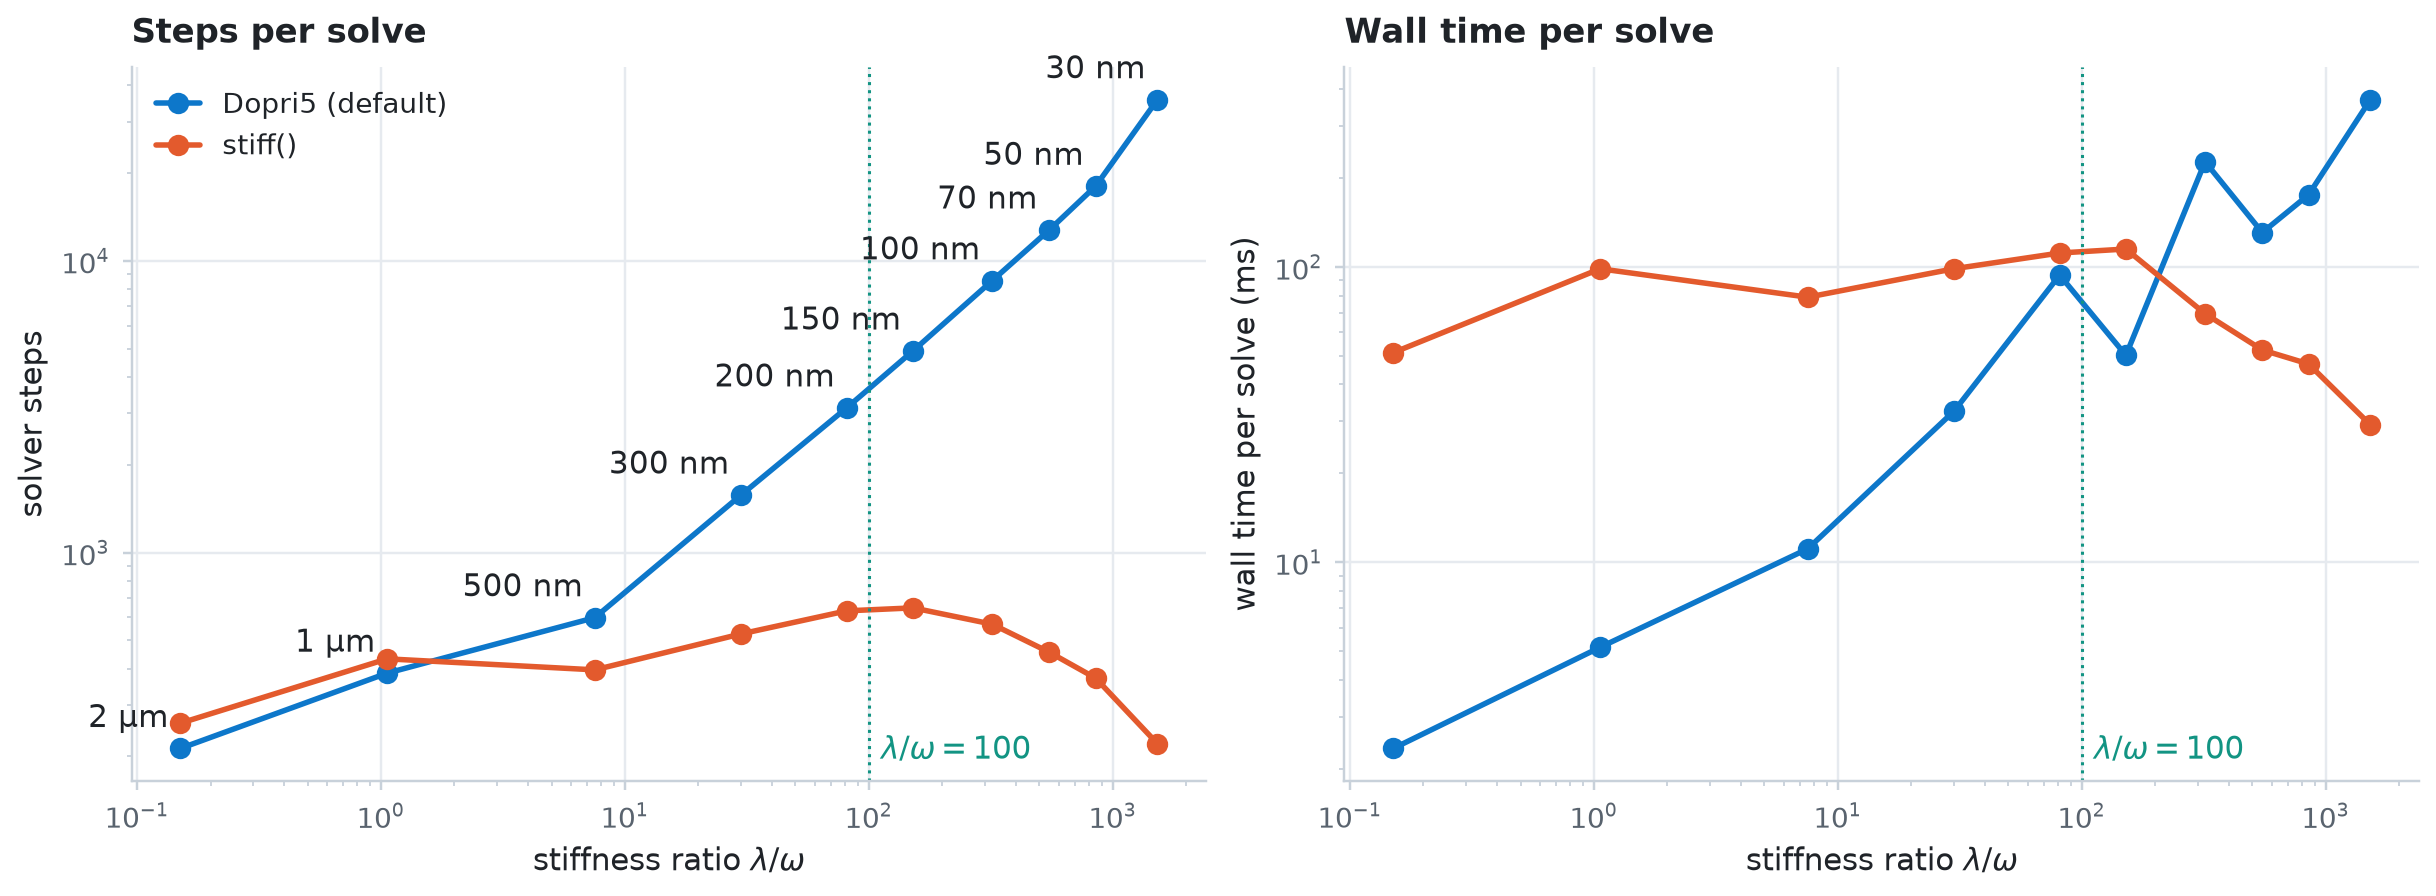

In [5]:
fig, (ax_steps, ax_time) = plt.subplots(
    1, 2, figsize=(11, 4), sharex=True, layout="constrained"
)
for colour, name in zip(["C0", "C1"], solvers, strict=True):
    ax_steps.plot(ratios, steps[name], "o-", color=colour, label=name)
    ax_time.plot(ratios, times[name], "o-", color=colour, label=name)
for R0, ratio, n in zip(radii, ratios, steps["Dopri5 (default)"], strict=True):
    label = f"{R0 * 1e6:g} µm" if R0 >= 1e-6 else f"{R0 * 1e9:.0f} nm"
    ax_steps.annotate(
        label, (ratio, n), textcoords="offset points", xytext=(-4, 7), ha="right"
    )
for ax in (ax_steps, ax_time):
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.axvline(100, color="C2", ls=":", lw=1)
    ax.set_xlabel("stiffness ratio $\\lambda/\\omega$")
ax_steps.set_ylabel("solver steps")
ax_steps.set_title("Steps per solve")
ax_time.set_ylabel("wall time per solve (ms)")
ax_time.set_title("Wall time per solve")
for ax in (ax_steps, ax_time):
    ax.annotate(
        "$\\lambda/\\omega = 100$",
        xy=(100, 0.03),
        xycoords=("data", "axes fraction"),
        xytext=(4, 0),
        textcoords="offset points",
        color="C2",
    )
ax_steps.legend(loc="upper left")
plt.show()

`Dopri5`'s step count grows in proportion to $\lambda/\omega$: it steps at the edge of its stability region, not at the accuracy it needs. The implicit `Kvaerno5` solver takes a few hundred steps at any size, but each step solves a nonlinear system, so it's several times slower per step, and it compiles in seconds instead of under one. It wins the race only for the stiffest bubbles. The printed crossover depends on the machine and on what else it's running; it typically falls between $\lambda/\omega$ of about 80 and 350.

## A stiff member slows the whole batch

Under `jax.vmap`, as in a `GridSweep`, the batch runs until its slowest member finishes. One stiff bubble among easy ones makes every member wait.

In [6]:
steps_of = jax.jit(jax.vmap(lambda R0: solve(R0, default)[1]))
easy = jnp.full(64, 2e-6)
mixed = easy.at[-1].set(50e-9)
t_easy = wall_time(steps_of, easy, repeats=repeats)
t_mixed = wall_time(steps_of, mixed, repeats=repeats)
print(f"64 bubbles of 2 µm:                {t_easy * 1e3:6.1f} ms")
print(f"63 bubbles of 2 µm and one of 50 nm: {t_mixed * 1e3:6.1f} ms")

64 bubbles of 2 µm:                  21.4 ms
63 bubbles of 2 µm and one of 50 nm: 1632.5 ms


## When the step budget runs out

A 10 nm bubble needs more than the default 100 000 `Dopri5` steps. The solve stops early, the samples after that point are `inf`, and `result.converged` is `False`. Called outside `jax.jit` and `jax.vmap`, `run_simulation` also warns; inside them, check `converged` yourself.

In [7]:
tiny = lipid_bubble(R0=10e-9, freq=FREQ, pressure=100e3, cycle_num=5)
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    result = run_simulation(tiny.eom, tiny.pulse)
print(f"Dopri5:   converged = {bool(result.converged)}, ", end="")
print(f"{int(jnp.isinf(result.radius).sum())} of {result.radius.size} samples are inf")
for w in caught:
    print(textwrap.fill(f"warning: {w.message}", width=78, subsequent_indent="  "))

result = run_simulation(tiny.eom, tiny.pulse, config=stiff)
print(f"stiff():  converged = {bool(result.converged)}")

Dopri5:   converged = False, 113 of 1024 samples are inf
  after the failure are inf. Check `result.converged`. If the solver reached
  `max_steps`, raise `SolverConfig(max_steps=...)`, or use
  `SolverConfig.stiff()` for a stiff problem.


stiff():  converged = True


## Gradients need the implicit solver

On a stiff problem, a converged `Dopri5` solve can still give a useless gradient. Differentiate a loss on the radius of a 20 nm bubble with respect to the shell viscosity $\kappa_s$. Both solvers agree on the radius, but only `stiff()` gives a finite gradient. Check it against a central difference of the accurate `Dopri5` forward solution.

In [8]:
R0_SMALL = 20e-9


def loss(kappa_s, config):
    eom, pulse = lipid_bubble(
        R0=R0_SMALL, freq=FREQ, pressure=100e3, cycle_num=5, kappa_s=kappa_s
    )
    res = run_simulation(eom, pulse, save_spec=SaveSpec(num_samples=256), config=config)
    return jnp.mean((res.radius / R0_SMALL - 1.0) ** 2)


forward = jax.jit(lambda k: loss(k, default))
h = 1e-12
central = (forward(KAPPA_S + h) - forward(KAPPA_S - h)) / (2 * h)
for name, config in [("Dopri5", default), ("stiff()", stiff)]:
    t0 = time.perf_counter()
    grad = jax.jit(jax.grad(partial(loss, config=config)))(KAPPA_S)
    print(
        f"{name:8s} d loss / d kappa_s = {float(grad):+.5g}  "
        f"({time.perf_counter() - t0:.1f} s with compilation)"
    )
print(f"central difference          = {float(central):+.5g}")

Dopri5   d loss / d kappa_s = +nan  (12.7 s with compilation)


stiff()  d loss / d kappa_s = -7.2055  (20.5 s with compilation)
central difference          = -7.2056


## Choosing a configuration

- Keep the default `SolverConfig()` for microbubbles in water, where $\lambda/\omega$ is below about 10: it's the fastest, both to compile and to run.
- Use `SolverConfig.stiff()` for nanobubbles, sub-micron bubbles in viscous liquids, and any problem with $\lambda/\omega \gtrsim 100$, above all when you differentiate.
- Check `result.converged`, or `diffrax.is_successful(sol.result)`, whenever a solve runs under `jax.jit` or `jax.vmap`.
- For a long pulse, raise `max_steps`; it costs neither memory nor compile time under `jax.grad`.
- To change the implicit solver's tolerances, call `SolverConfig.stiff(rtol=..., atol=...)`, so its Newton tolerances follow.